# 历年国赛 / 美赛中的评价与决策问题｜核心突破实战课件

> 4 道真实往年赛题的教学化求解：题目是什么 → 评价和决策各走哪条流程 → 权重怎么来 → 优化怎么接到评价上 → 代码怎么跑 → 结论怎么写。

## 先说明这份课件的边界

这不是历年获奖论文的复制，也不是声称给出赛题唯一答案。数学建模竞赛本来就没有唯一标准模型。本课件做的是：

1. 选取真实往年赛题；
2. 保留题目的核心机制；
3. 为了让初学者能独立运行，使用明确写出的**教学参数或简化数据**；
4. 给出一套逻辑完整、能运行、能解释、能继续扩展的基线方案。

如果正式参赛，必须进一步使用官方附件、估计参数、做严格验证，并按题目要求完成论文。

## 本课选取的 4 道题

|年份与赛事|题目|主要方法|本课回答的核心问题|
|---|---|---|---|
|2020 全国大学生数学建模竞赛 C 题|中小微企业的信贷决策|熵权-TOPSIS、流失率拟合、额度利率规划|怎样把发票和信誉变成“放不放、放多少、利率多少”？|
|2021 全国大学生数学建模竞赛 C 题|生产企业原材料的订购与运输|供应商综合评价、最小覆盖、订购与转运|怎样选出真正重要的供应商，并制定 24 周计划？|
|2024 全国大学生数学建模竞赛 C 题|农作物的种植策略|约束规划、滞销处理、不确定性情景|地块、轮作和超产降价下，七年种什么？|
|2023 ICM Problem D|Prioritizing the UN Sustainability Goals|影响网络、中心性、优先级评价|17 个目标互相牵扯时，先推哪几个最有效？|

## 学完应该会什么？

- 能区分**评价问题**（给对象打分排序）和**决策问题**（在约束下选行动）；
- 能独立完成：对象/准则 → 预处理与一致化 → 赋权 → 集结 → 敏感性 → 接到规划；
- 知道 AHP、熵权、CRITIC、TOPSIS、灰色关联各自解决哪一段，而不是“看到评价就 AHP”；
- 能解释权重一变、排序为什么会变，并给出稳健结论；
- 能把评价分数写成规划里的目标或约束；
- 能在论文里写清假设、局限和“正式参赛还应补什么”。

## 资料来源与题目真实性

- [全国大学生数学建模竞赛历年赛题汇总](https://www.mcm.edu.cn/html_cn/node/a0c1fb5c31d43551f08cd8ad16870444.html)
- [2023 ICM Problem D：Prioritizing the UN Sustainability Goals](https://www.contest.comap.com/undergraduate/contests/mcm/contests/2023/problems/)
- [2020 国赛 C 题公开题面（信贷决策）](https://www.mcm.edu.cn/)
- [2021 国赛 C 题公开题面（原材料订购与运输）](https://www.mcm.edu.cn/)
- [2024 国赛 C 题公开题面（农作物的种植策略）](https://www.mcm.edu.cn/)

本 Notebook 对官方题意做中文概括，不大段复制题面。演示数据均在对应章节标注，**不能当作官方附件或现实决策依据**。

# 0. 评价问题、决策问题，分别是什么？

## 0.1 先把两类问题分开，再看它们怎样耦合

### 评价问题

给定一批**对象**（企业、供应商、地块方案、SDG）和一组**准则**（风险、信誉、供货稳定性、中心性），要给出：

- 综合得分；
- 排序 / 分级；
- 有时还要阈值：谁合格、谁淘汰。

数学上是一个集结映射：

$$
S_i = F(z_{i1},z_{i2},\ldots,z_{im};\, w),\qquad i=1,\ldots,n.
$$

其中 $z_{ij}$ 是对象 $i$ 在准则 $j$ 上已经同向、同量纲后的得分，$w$ 是权重。

### 决策问题

要选择**行动** $x$（贷多少、向谁订、哪块地种什么、先投资哪个目标），使得目标最优且满足约束：

$$
\max_x\ U(x)\quad \text{s.t.}\quad g_k(x)\le 0,\ \ x\in X.
$$

$x$ 可以是连续额度，也可以是 0-1 选址、整数种植面积。

### 竞赛里更常见的是“评价 + 决策”

|阶段|输出|下一阶段怎么用|
|---|---|---|
|评价|风险分、重要性、优先级|进入目标函数或筛选约束|
|决策|额度、订单、种植表、投资组合|用评价分解释“为什么这样选”|

**核心突破 1**：只排序不决策，或只优化不评价，都只做了半道题。2020 C、2021 C 都是标准的“先评价后规划”。

## 0.2 题面识别口诀

看到这些词，优先走评价：

- 评估、评价、评级、排序、重要性、优先级、优劣、权重、指标体系。

看到这些词，优先走决策：

- 策略、方案、分配、调度、选址、种植、订购、最大收益、最小风险、在……约束下。

两者同时出现，就按“指标体系 → 权重 → 得分 → 优化模型”写论文结构。

## 0.3 评价决策题最容易丢分的 8 个坑

1. **准则不独立**：销售额、利润、利润率一起进模型，信息重复，权重虚高。
2. **方向没改**：把成本、损耗、逾期当效益型，排名会反。
3. **量纲没处理**：发票金额 10^6 和信誉 1–4 直接加权。
4. **权重拍脑袋**：AHP 矩阵随意填，一致性也不检验。
5. **一种方法定终身**：只用 TOPSIS，不做熵权/灰色/主成分对照。
6. **排序当决策**：得分最高的 50 家未必能覆盖产能，还缺约束。
7. **不谈敏感性**：权重 ±20% 排名大洗牌，却声称方案稳健。
8. **目标函数会飞**：收益最大但允许无限贷、无限种，最优解不在可行业务里。

# 0.4 评价问题的完整流程

$$
\boxed{对象与目标 \rightarrow 准则体系 \rightarrow 数据与方向 \rightarrow 一致化 \rightarrow 赋权 \rightarrow 集结打分 \rightarrow 分级 \rightarrow 敏感性 \rightarrow 对接决策}
$$

## 第一步：先写评价合同

|合同项|必须写清|
|---|---|
|评价对象|123 家有信贷记录企业 / 402 家供应商 / 17 个 SDG|
|评价目的|筛选、排序、分级，还是给规划当权重|
|决策者|银行、工厂、乡村、联合国|
|时间窗口|近 1 年发票、近 240 周供货、当前 SDG 进度|
|合格标准|前 50、风险低于阈值、还是连续分数|

目的不同，准则就不同。给“淘汰最差 10%”和给“分配 1 亿元额度”不是同一套指标。

## 第二步：建准则体系——少而硬，不要多而软

一个能写进论文的体系通常 2–4 个一级准则，每个下面 2–4 个可计算的二级指标。

|一级|二级必须可计算|反例|
|---|---|---|
|实力|有效开票额、毛利、上下游集中度|“企业形象好”|
|信誉|信誉等级编码、作废发票率、逾期次数|“听说守信”|
|稳定|供货变异系数、履约率、断供周数|“合作愉快”|
|效率|单位产能原料、损耗率|把稳定再复制一遍|

**核心突破 2**：每个指标都要能指出附件中的列和计算公式。写不出公式的指标，删掉。

检查三件事：

1. **完备**：决策者在乎的方面都覆盖了；
2. **独立**：两两相关不要长期高于 0.9；
3. **可操作**：现在就能算，不依赖赛后才有的数据。

## 第三步：数据预处理与方向一致化

### 3.1 清洗

- 缺失：组内中位数 + 缺失指示；信誉缺失不能随便当 A。
- 异常：作废发票率 > 1、供货为负，先核对口径。
- 分类有序：信誉 A/B/C/D → 4/3/2/1，要在论文声明编码方向。

### 3.2 效益型 / 成本型

$$
\text{效益型：越大越好（销售额、履约率）},\quad
\text{成本型：越小越好（逾期、损耗、流失）}.
$$

### 3.3 常用无量纲

设 $x_{ij}$ 为原始值。

**极差（min-max）**

$$
z_{ij}=\frac{x_{ij}-\min_i x_{ij}}{\max_i x_{ij}-\min_i x_{ij}}\quad(\text{效益}),\qquad
z_{ij}=\frac{\max_i x_{ij}-x_{ij}}{\max_i x_{ij}-\min_i x_{ij}}\quad(\text{成本}).
$$

**向量归一（TOPSIS 常用）**

$$
z_{ij}=\frac{x_{ij}}{\sqrt{\sum_i x_{ij}^2}}.
$$

**Z-score**：适合接近正态、要做主成分时；有极端值时被绑架。

**核心突破 3**：归一化必须在“当前评价集合”上做。新增 302 家无记录企业时，要说明是沿用 123 家的 min/max，还是重新计算。

## 第四步：赋权——主观、客观、组合

权重是评价题里**最敏感、最容易被问倒**的部分。

|方法|信息来自哪里|优点|风险|
|---|---|---|---|
|AHP / 最优最劣法|专家两两比较|能体现银行政策|矩阵乱填、一致性差|
|熵权|数据离散程度|谁区分度大谁权重大|区分度 ≠ 重要性|
|CRITIC|对比强度 + 冲突|考虑指标相关性|解释成本高|
|主成分 / 因子|方差贡献|降维|第一主成分未必等于“好坏”|
|组合赋权|$\lambda w^{主观}+(1-\lambda)w^{客观}$|稳健|$\lambda$ 仍要敏感性|

熵权公式（效益型标准化后 $p_{ij}=z_{ij}/\sum_i z_{ij}$）：

$$
e_j=-\frac{1}{\ln n}\sum_i p_{ij}\ln p_{ij},\qquad
w_j=\frac{1-e_j}{\sum_k(1-e_k)}.
$$

AHP 必须报告一致性比 $CR=CI/RI$。经验上 $CR\ge 0.1$ 要重填判断矩阵。

**核心突破 4**：论文至少给出“主观一套 + 客观一套”，并比较排序的 Spearman 相关。相关高，才敢说结论不依赖一种权重哲学。

## 第五步：集结打分——方法要对任务

|方法|在做什么|适合|不适合|
|---|---|---|---|
|加权和 $S_i=\sum w_j z_{ij}$|线性补偿|指标可互相替代|短板不可被弥补时|
|加权积|惩罚短板|安全、信誉有一票否决|有 0 值|
|TOPSIS|距正理想近、负理想远|排序、与样本有关|样本一变，理想点会变|
|VIKOR|群体效用 + 最大遗憾|需要平衡公平时|参数 $v$ 要讨论|
|灰色关联|与参考序列的形状相似|小样本、趋势|参考序列怎么选|
|DEA|输入输出效率|供应商效率|只有产出没有投入时别硬套|
|模糊综合|隶属度|语言评价多|隶属函数拍脑袋|
|PageRank / 中心性|网络地位|SDG、舆情、引用|没有边就不要硬造|

TOPSIS 的核心：

$$
C_i=\frac{D_i^-}{D_i^++D_i^-},\qquad
D_i^\pm=\sqrt{\sum_j(v_{ij}-v_j^\pm)^2},\ \ v_{ij}=w_j z_{ij}.
$$

$C_i$ 越接近 1 越好。

## 第六步：分级、阈值与解释

排序之后题目往往还要“策略”。需要额外规则：

- 前 20% 优先授信，中间审慎，后 10% 拒绝；
- 或用聚类把连续分数分成 3–4 档，避免人为切一刀。

解释时用：

- 指标贡献分解：$w_j z_{ij}$ 谁拉低了得分；
- 对照案例：为什么 A 企业分高、B 企业分低。

## 第七步：评价的验证指标

评价没有唯一 $y$，但仍可验证。

|验证|做法|
|---|---|
|内部一致性|AHP 的 $CR$；多方法 Spearman $\rho$|
|区分度|各组箱线是否分开；与已知标签（信誉等级）的相关|
|稳定性|留一法、权重扰动、样本扰动后的排名变化率|
|回测|若有历史违约 / 断供，看高风险组是否更常出事|
|常识|规模很小却得分第一，多半是归一化被极端值带偏|

**不要**用“我们的评价很合理”当验证。

# 0.5 决策问题的完整流程

$$
\boxed{决策变量 \rightarrow 目标 \rightarrow 约束 \rightarrow 不确定性 \rightarrow 求解 \rightarrow 对照情景 \rightarrow 稳健性}
$$

## 第一步：把“策略”翻译成变量

|题|变量|
|---|---|
|信贷|企业 $i$ 的 0-1 放贷 $y_i$，额度 $x_i$，利率 $r_i$|
|订购|第 $t$ 周向供应商 $i$ 订 $q_{it}$，由转运商 $k$ 运 $z_{itk}$|
|种植|地块 $p$、作物 $c$、年 $y$、季 $s$ 的面积 $a_{pcys}$|
|SDG|未来 10 年对目标 $g$ 的优先级 / 资源份额 $u_g$|

写不出变量，就还停留在作文。

## 第二步：目标函数要对银行/工厂/乡村说得通

常见目标：

- 期望利润、期望产量；
- 风险调整收益：$\mathbb{E}[\pi]-\lambda \mathrm{CVaR}$；
- 多目标：成本、损耗、多样性，再加权或求 Pareto。

信贷里一个能讲清的期望收益：

$$
\mathbb{E}[\pi_i]=(1-p_i)\,x_i r_i - p_i\, x_i L_i,
$$

$p_i$ 是违约概率，$L_i$ 是违约损失率。没有 $p_i$ 时，可用评价风险分做单调变换。

## 第三步：约束要比目标更认真

竞赛里约束写漏，模型会给出“数学最优、业务荒谬”的解。

必须逐条对应题面：

- 额度上下限、总预算；
- 供应商每周产能、转运商运力、损耗；
- 地块类型匹配、不能重茬、三年至少一次豆类、最小连片面积；
- 超产：浪费或半价。

**核心突破 5**：先写“题面约束清单”，再写公式。评委按清单对。

## 第四步：不确定性怎么进模型

|处理|含义|2024 种植 / 2020 信贷|
|---|---|---|
|情景|中/悲观/乐观各解一次|价格 ±5%、疫情冲击|
|随机规划|对分布求期望|销售量均匀扰动|
|稳健优化|最坏允许扰动下最优|亩产 ±10% 的最坏|
|机会约束|以 $1-\alpha$ 概率满足|产能不低于 2.82 万的概率|

课件里至少做**情景 + 敏感性**。真正参赛再上随机/稳健。

## 第五步：求解与验证

- 线性 / 整数：`PuLP`、`scipy.optimize`、贪心 + 局部改进；
- 非线性：网格、多起点；
- 先求放松连续解，再圆整，检查约束。

验证：

1. 把解代回约束，打印最大违反量；
2. 和朴素策略比：平均分配、只选评价前 $k$、去年种什么今年还种什么；
3. 权重、价格、违约率扰动后，决策变量的变化。

## 0.6 评价怎样接到决策——四种标准接口

1. **筛选**：评价分低于阈值，$y_i=0$。
2. **目标加权**：$\max \sum S_i x_i$ 或 $\min \sum (1-S_i)x_i$。
3. **分层**：先满足 A 级企业，再考虑 B 级。
4. **风险预算**：$\sum p_i x_i \le \bar R$。

论文里画一张“评价模块 → 决策模块”的流程图，比堆公式更加分。

## 0.7 评价决策题的论文指标清单

- 评价：权重表、得分表、与已知标签的相关、Spearman（多方法）、扰动后 Top-K 重合率。
- 决策：目标值、约束满足、对照策略的改进百分比、情景表。
- 共同：假设、局限、数据口径。

## 0.8 环境准备

运行下面单元。后面的表格和图片均由代码真实计算，不是手工贴图。

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, KFold, cross_val_score
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans

try:
    import statsmodels.api as sm
    HAS_SM = True
except Exception:
    HAS_SM = False

try:
    from IPython.display import display
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic('matplotlib', 'inline')
except Exception:
    display = print

SEED = 2026
rng = np.random.default_rng(SEED)
COLORS = {
    'navy': '#16324F', 'blue': '#2878B5', 'cyan': '#2A9D8F',
    'yellow': '#E9C46A', 'orange': '#F4A261', 'red': '#E76F51',
    'purple': '#7B6DCC', 'gray': '#7A8793', 'green': '#43AA8B'
}

_installed = {f.name for f in font_manager.fontManager.ttflist}
for _name in ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Noto Sans SC', 'Arial Unicode MS']:
    if _name in _installed:
        plt.rcParams['font.sans-serif'] = [_name] + list(plt.rcParams.get('font.sans-serif', []))
        break
plt.rcParams.update({
    'figure.figsize': (10, 5.4), 'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.20,
    'axes.unicode_minus': False
})


def show_result(table=None, fig=None):
    if globals().get('BUILDING_NOTEBOOK', False):
        return
    if table is not None:
        display(table)
    if fig is not None:
        plt.show()


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.abs(y_true) > eps
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])))


def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(np.mean(2.0 * np.abs(y_true - y_pred) / denom))


def regression_report(y_true, y_pred, name='model'):
    return {
        '模型': name,
        'RMSE': rmse(y_true, y_pred),
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'MAPE': mape(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred),
        'R2': float(r2_score(y_true, y_pred)),
    }


def minmax_norm(x, benefit=True):
    x = np.asarray(x, dtype=float)
    lo, hi = np.nanmin(x), np.nanmax(x)
    if hi - lo < 1e-12:
        return np.ones_like(x) * 0.5
    z = (x - lo) / (hi - lo)
    return z if benefit else 1.0 - z


print('环境就绪：NumPy', np.__version__, '| Pandas', pd.__version__,
      '| statsmodels', '是' if HAS_SM else '否')

环境就绪：NumPy 2.5.1 | Pandas 3.0.5 | statsmodels 是


# 案例一｜2020 国赛 C 题：中小微企业的信贷决策

> 把银行当作一个必须把有限的钱，借给“看起来最值得借、借了还回得来”的小企业的人。你不会做复杂机器学习也没关系：先打分，再算期望能赚多少，再在总额用完之前排队放贷。下面每个专有名词和每个字母都用人话解释。

## 1.1 专有名词先扫盲（上课看不懂多半卡在这里）

- **中小微企业**：规模小、常常没有厂房土地可抵押。银行不能只看“有没有房子”，只能看它平时买卖开的发票、过往有没有违约。
- **信贷**：银行把钱借出去，到期连本带息收回。本课期限固定为 1 年。
- **信誉等级**：附件里常见 A/B/C/D。A 最好，D 最差。这是银行已经打过的标签，第 1 问可以直接用；第 2 问 302 家没有这个标签，必须自己预测。
- **违约**：到期没按约定还钱。历史违约 = 过去已经发生过。
- **进项发票 / 销项发票**：进项是企业买东西收到的票（成本侧），销项是企业卖东西开出的票（收入侧）。有效开票额大，通常说明生意更大。
- **作废发票率**：开了又作废的票 / 全部票。太高可能虚假交易或经营混乱。
- **上游集中度**：进货是不是只靠少数几家。太集中，一家出事它就断粮。
- **下游稳定度**：客户是否长期稳定下单。
- **流失率**：你把利率定高了，客户嫌贵，转到别的银行。利率越高，流失通常越高。
- **额度**：借多少钱，本题规定 10～100 万元。
- **年利率**：一年利息占本金的比例。4% 表示借 100 万，一年利息 4 万。
- **LGD（违约损失率）**：一旦违约，本金里大概有多大比例收不回来。本课取 0.65，表示违约了大约亏掉 65% 本金。
- **期望利润**：把“客户留下、按时还”和“客户走了 / 违约了”几种情况，按概率加权以后的平均赚钱数。不是保证能赚到的数。

## 1.2 三问分别要你在论文里交什么

**第 1 问：** 123 家有信贷记录。先给每家一个风险/信誉分数，再在“今年总共只能贷这么多”的前提下，决定：贷不贷、贷多少、利率多少。

**第 2 问：** 302 家没有信誉标签。用第 1 问学会的“发票 → 分数”的方法给它们打分，总额改成 **1 亿元**，再给策略。

**第 3 问：** 突发因素（例如疫情）对不同行业伤害不同。餐饮可能比信息服务更惨。把违约概率或销售额打一个行业折扣，重新分配 1 亿元。

## 1.3 第 1 问怎么写：先评价，再决策

整条链用人话串起来：

> 从发票算出几项能计算的指标 → 把量纲不同的指标拉到 0～1 → 给每项一个权重 → 合成一个“越安全越高”的分数 $S_i$ → 把 $S_i$ 翻译成违约概率 $p_i$ → 再结合利率造成的流失，算期望利润 → 总额不够时，优先装期望利润/额度高的企业。

### 第一步：把每个指标变成 0 到 1，并且方向一致

有的指标越大越好，叫**效益型**（开票额、信誉分、下游稳定度）。有的越小越好，叫**成本型**（作废率、上游集中度、历史违约）。

$$
z_{ij}=\frac{x_{ij}-\min_i x_{ij}}{\max_i x_{ij}-\min_i x_{ij}}\quad\text{效益型},\qquad
z_{ij}=\frac{\max_i x_{ij}-x_{ij}}{\max_i x_{ij}-\min_i x_{ij}}\quad\text{成本型}.
$$

|符号|人话|
|---|---|
|$x_{ij}$|第 $i$ 家企业、第 $j$ 个原始指标。比如第 3 家的作废发票率|
|$\min_i x_{ij}$|这一列在全部企业里的最小值|
|$\max_i x_{ij}$|这一列的最大值|
|$z_{ij}$|标准化以后的分数，一定在 0 和 1 之间，**越大一律表示越好**|

为什么必须这一步：开票额是几百，信誉分只有 1～4，直接相加，开票额会把信誉完全淹死。

### 第二步：熵权——谁更能把企业区分开，谁权重大

**熵**：信息论里衡量“有多乱、有多不确定”。某一列如果大家都差不多，这一列几乎不提供区分信息，熵就大，权重就该小。

先把 $z_{ij}$ 变成比例 $p_{ij}=z_{ij}/\sum_i z_{ij}$（这一列加起来为 1，像概率）。

$$
e_j=-\frac{1}{\ln n}\sum_{i=1}^{n}p_{ij}\ln p_{ij},\qquad
w_j=\frac{1-e_j}{\sum_k(1-e_k)}.
$$

|符号|人话|
|---|---|
|$n$|企业个数|
|$e_j$|第 $j$ 个指标的熵，介于 0 和 1。越接近 1，大家越像，越没区分度|
|$1-e_j$|区分度。谁区分度大，谁权重大|
|$w_j$|最终权重，所有 $w_j$ 加起来等于 1|
|$\ln$|自然对数。公式前面除以 $\ln n$ 是为了把熵压到 0～1|

注意：熵权说的是“数据里谁变化大”，**不等于**“银行政策上谁更重要”。所以必须再算一套**等权**（每个 $w_j=1/m$）对照。

### 第三步：TOPSIS——离“理想企业”有多近

**TOPSIS** 的中文意思：逼近理想解的排序法。想象有一个“每项都最好”的正理想，和一个“每项都最差”的负理想。谁离正理想近、离负理想远，谁分高。

$$
v_{ij}=w_j z_{ij},\quad
D_i^+=\sqrt{\sum_j(v_{ij}-v_j^+)^2},\quad
D_i^-=\sqrt{\sum_j(v_{ij}-v_j^-)^2},\quad
S_i=\frac{D_i^-}{D_i^++D_i^-}.
$$

|符号|人话|
|---|---|
|$v_{ij}$|加权以后的坐标，相当于把重要的指标轴拉长|
|$v_j^+$|第 $j$ 项上所有企业里最好的那个值（正理想）|
|$v_j^-$|第 $j$ 项上最差的那个值（负理想）|
|$D_i^+$|企业 $i$ 离正理想有多远，越小越好|
|$D_i^-$|离负理想有多远，越大越好|
|$S_i$|综合接近度，在 0 和 1 之间。**本课把它当“越安全越高”的评价分**|

再算一套等权得到 $S_i^{\mathrm{eq}}$，报告 Spearman 相关系数 $\rho$（两个排序像不像）。$\rho$ 接近 1，说明结论不太吃“用哪种权重哲学”。

### 第四步：分数变成违约概率，利率变成流失率

$$
p_i=\mathrm{clip}(0.22-0.25 S_i+0.15\cdot\mathbf{1}_{\{\text{曾违约}\}},\,0.02,\,0.55).
$$

|符号|人话|
|---|---|
|$p_i$|估计的违约概率。0.08 表示平均 100 家里大约 8 家会违约|
|$0.22-0.25S_i$|分数越高，违约概率越低。系数是教学取值，正式参赛应用历史违约回拟合|
|$\mathbf{1}_{\{\text{曾违约}\}}$|曾经违约过则为 1，否则为 0|
|$\mathrm{clip}(\cdot,0.02,0.55)$|不允许概率小于 2% 或大于 55%，避免极端|

流失率随利率升高：

$$
c(r)=\frac{1}{1+e^{-22(r-0.10)}}.
$$

|符号|人话|
|---|---|
|$r$|年利率，例如 0.08 表示 8%|
|$c(r)$|在这个利率下，客户流失（不贷了）的概率|
|$0.10$|大约在 10% 利率附近，流失开始变得很快|
|$22$|曲线有多陡。越大，过了 10% 以后流失涨得越猛|

### 第五步：期望利润和总额约束

一家企业借 $x$ 万元、利率 $r$，期望利润

$$
\mathbb{E}[\pi_i]=(1-c(r))\big[(1-p_i)xr - p_i x\cdot\mathrm{LGD}\big].
$$

|符号|人话|
|---|---|
|$x$|额度，万元，必须在 10～100|
|$(1-c(r))$|客户愿意留下来的概率。利率太高，这项接近 0，再高的利息也赚不到|
|$(1-p_i)xr$|没违约时，银行收到的利息|
|$p_i x\cdot\mathrm{LGD}$|违约时亏掉的本金期望|
|$\mathbb{E}[\pi_i]$|综合考虑留下、还钱、违约之后，平均能赚多少|

对每家在额度、利率的小格子上选使 $\mathbb{E}[\pi_i]$ 最大的 $(x_i,r_i)$。然后年度总额 $B$（第 1 问教学用 800 万，第 2 问官方 1 亿）：

$$
\max_{y_i\in\{0,1\}}\sum_i y_i\mathbb{E}[\pi_i]\quad\text{s.t.}\quad\sum_i y_i x_i\le B.
$$

|符号|人话|
|---|---|
|$y_i=1$|决定放贷；$y_i=0$ 拒绝|
|$B$|今年总共能贷出去的钱|

本课按“利润密度”$\mathbb{E}[\pi_i]/x_i$ 从高到低贪心装包。正式参赛应写成整数规划。

## 1.4 第 2、3 问怎么写

第 2 问：用 123 家训练一个从发票特征到 $S$ 或信誉等级的模型（逻辑回归即可），预测 302 家，再把 $B=10^8$。划分必须按**企业**，不能把同一家的发票行拆到训练和测试两边。

第 3 问：给行业 $s$ 一个冲击 $\gamma_s$（餐饮 0.4，信息服务 0.05），令 $p_i'=p_i(1+\gamma_{s(i)})$，重新跑配置。论文交一张“调整前后放贷名单变化表”。

In [2]:
def make_credit_firms(n=24, seed=2026):
    r = np.random.default_rng(seed)
    industries = ['零售','制造','餐饮','物流','建材','信息服务']
    rows = []
    for i in range(n):
        strength = r.uniform(0.25, 1.0)
        reputation = r.choice(['A','B','C','D'], p=[0.22, 0.40, 0.28, 0.10])
        rep_map = {'A': 4, 'B': 3, 'C': 2, 'D': 1}
        defaulted = int(r.random() < {'A':0.03,'B':0.08,'C':0.18,'D':0.40}[reputation])
        invoice_valid = 80 + 900 * strength + r.normal(0, 40)
        invoice_void_rate = np.clip(0.02 + 0.12 * (4 - rep_map[reputation]) / 3 + r.normal(0, 0.02), 0.005, 0.35)
        up_conc = np.clip(r.beta(2, 5) + 0.1 * (reputation == 'D'), 0.05, 0.9)
        down_stable = np.clip(0.4 + 0.5 * strength - 0.1 * defaulted + r.normal(0, 0.05), 0.1, 0.98)
        rows.append({
            '企业': f'F{i+1:02d}', '行业': r.choice(industries),
            '信誉': reputation, '信誉分': rep_map[reputation],
            '历史违约': defaulted,
            '有效开票额': max(invoice_valid, 20),
            '作废发票率': invoice_void_rate,
            '上游集中度': up_conc,
            '下游稳定度': down_stable,
        })
    return pd.DataFrame(rows)

firms = make_credit_firms()
print('教学企业', len(firms), '家。官方附件还需从进销项发票逐张汇总这些特征。')
show_result(firms.head(8))

教学企业 24 家。官方附件还需从进销项发票逐张汇总这些特征。


,企业,行业,信誉,信誉分,历史违约,有效开票额,作废发票率,上游集中度,下游稳定度
0,F01,零售,C,2,0,481.611868,0.112766,0.197456,0.580805
1,F02,信息服务,C,2,0,932.335511,0.087720,0.214354,0.846080
2,F03,信息服务,C,2,1,621.539106,0.136492,0.267221,0.528116
3,F04,信息服务,B,3,0,888.795734,0.042289,0.420243,0.867884
4,F05,建材,C,2,0,539.320987,0.111879,0.471373,0.780628
5,F06,餐饮,C,2,0,604.522680,0.099567,0.140962,0.774923
6,F07,信息服务,D,1,1,876.944156,0.111378,0.275371,0.703419
7,F08,信息服务,A,4,0,700.812651,0.042400,0.406562,0.748982


## 1.3 本课使用的准则（方向必须先写清）

|准则|方向|含义|
|---|---|---|
|有效开票额|效益|规模与实力|
|信誉分|效益|历史信誉|
|下游稳定度|效益|需求是否稳|
|作废发票率|成本|票据质量差|
|上游集中度|成本|过于依赖少数供应商|
|历史违约|成本|直接风险标签|

下面先算熵权和 TOPSIS 分数，再把分数送进额度–利率网格。

In [3]:
crit = {
    '有效开票额': True, '信誉分': True, '下游稳定度': True,
    '作废发票率': False, '上游集中度': False, '历史违约': False
}

def entropy_weights(df, crit_dict):
    Z = []
    for col, benefit in crit_dict.items():
        Z.append(minmax_norm(df[col].to_numpy(), benefit=benefit))
    Z = np.vstack(Z).T
    P = Z / (Z.sum(axis=0, keepdims=True) + 1e-12)
    P = np.clip(P, 1e-12, 1)
    e = -(P * np.log(P)).sum(axis=0) / np.log(len(df))
    d = 1 - e
    w = d / d.sum()
    return Z, w

def topsis(Z, w):
    V = Z * w
    ideal, nadir = V.max(axis=0), V.min(axis=0)
    dp = np.sqrt(((V - ideal) ** 2).sum(axis=1))
    dn = np.sqrt(((V - nadir) ** 2).sum(axis=1))
    return dn / (dp + dn + 1e-12)

Z, w_ent = entropy_weights(firms, crit)
score = topsis(Z, w_ent)
# 等权对照
score_eq = topsis(Z, np.ones(len(w_ent)) / len(w_ent))
firms['风险调整分'] = score          # 越大越好（越安全）
firms['等权分'] = score_eq
w_tbl = pd.DataFrame({'准则': list(crit), '熵权': w_ent, '方向': ['效益' if v else '成本' for v in crit.values()]})
rank_corr = stats.spearmanr(firms['风险调整分'], firms['等权分']).statistic
print(f'熵权 TOPSIS 与等权 TOPSIS 的 Spearman ρ = {rank_corr:.3f}（越高说明不太吃权重哲学）')
show_result(w_tbl.round(3))
show_result(firms.sort_values('风险调整分', ascending=False)[['企业','行业','信誉','历史违约','风险调整分']].head(8))

熵权 TOPSIS 与等权 TOPSIS 的 Spearman ρ = 0.979（越高说明不太吃权重哲学）


,准则,熵权,方向
0,有效开票额,0.161,效益
1,信誉分,0.253,效益
2,下游稳定度,0.177,效益
3,作废发票率,0.138,成本
4,上游集中度,0.148,成本
5,历史违约,0.123,成本


,企业,行业,信誉,历史违约,风险调整分
20,F21,物流,A,0,0.781649
15,F16,制造,B,0,0.775749
16,F17,信息服务,A,0,0.705325
7,F08,信息服务,A,0,0.703920
3,F04,信息服务,B,0,0.699603
12,F13,信息服务,B,0,0.681740
11,F12,零售,B,0,0.606287
1,F02,信息服务,C,0,0.598906


,放贷家数,用信总额,组合期望利润,被拒家数
0,8,800,26.74,16


,企业,信誉,行业,评价分,违约概率,建议额度,建议利率,期望利润,利润密度,是否放贷
20,F21,A,物流,0.782,0.025,100,0.10,4.078,0.041,1
15,F16,B,制造,0.776,0.026,100,0.10,4.023,0.040,1
16,F17,A,信息服务,0.705,0.044,100,0.11,3.420,0.034,1
7,F08,A,信息服务,0.704,0.044,100,0.11,3.408,0.034,1
3,F04,B,信息服务,0.700,0.045,100,0.11,3.371,0.034,1
12,F13,B,信息服务,0.682,0.050,100,0.11,3.220,0.032,1
11,F12,B,零售,0.606,0.068,100,0.12,2.637,0.026,1
1,F02,C,信息服务,0.599,0.070,100,0.12,2.581,0.026,1
8,F09,B,零售,0.592,0.072,0,0.00,0.000,0.025,0
17,F18,C,制造,0.589,0.073,0,0.00,0.000,0.025,0


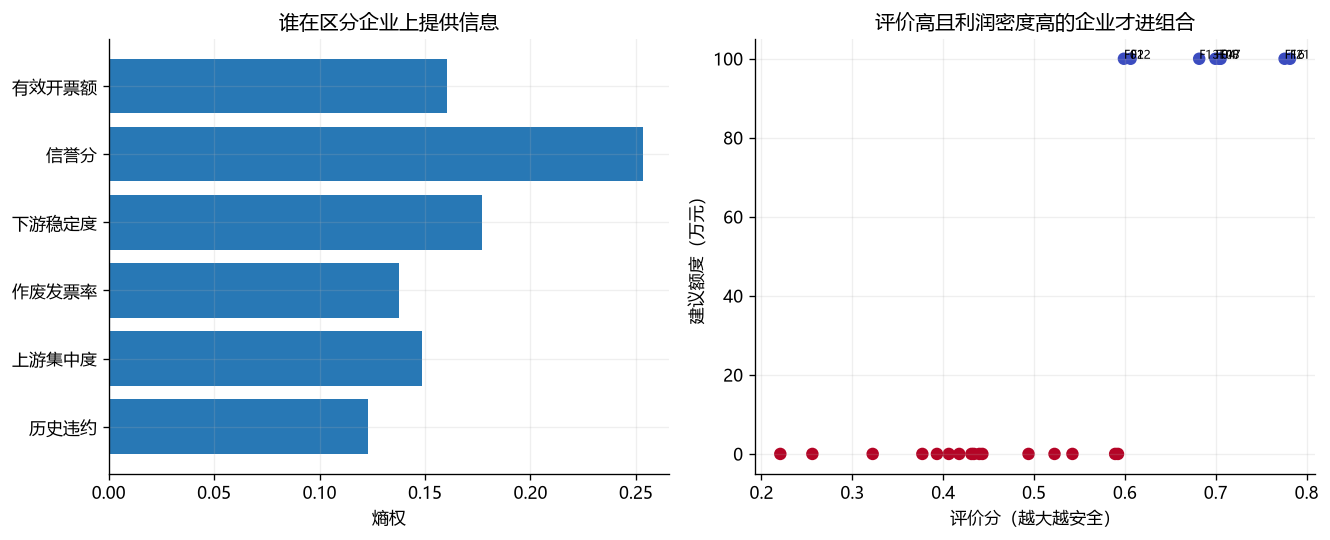

In [4]:
# 流失率：利率越高客户越容易走。教学拟合 r -> churn
rate_grid = np.array([0.04, 0.06, 0.08, 0.10, 0.12, 0.15])
churn_obs = np.array([0.00, 0.06, 0.18, 0.36, 0.55, 0.82])
# 用简单 logistic 形状
def churn(r):
    return 1 / (1 + np.exp(-22 * (r - 0.10)))

# 违约概率：由评价分单调映射，历史违约抬高
p_def = np.clip(0.22 - 0.25 * firms['风险调整分'] + 0.15 * firms['历史违约'], 0.02, 0.55)

# 决策：总额 800 万教学预算（对应第 1 问“总额固定”；第 2 问把数字换成 1 亿即可）
BUDGET = 800
LGD = 0.65   # 违约损失率

def expected_profit(x, r, p):
    stay = 1 - churn(r)
    return stay * ((1 - p) * x * r - p * x * LGD)

# 对每家企业在离散利率、额度网格上选期望利润最大的 (x,r)
xs = np.arange(10, 101, 5)
rs = np.linspace(0.04, 0.15, 12)
alloc = []
for i, row in firms.iterrows():
    best = (-1e9, 0, 0.04)
    for x in xs:
        for r in rs:
            val = expected_profit(x, r, p_def[i])
            if val > best[0]:
                best = (val, x, r)
    alloc.append({'企业': row['企业'], '信誉': row['信誉'], '行业': row['行业'],
                  '评价分': row['风险调整分'], '违约概率': p_def[i],
                  '建议额度': best[1], '建议利率': best[2], '期望利润': best[0]})
alloc = pd.DataFrame(alloc).sort_values('期望利润', ascending=False)

# 总额约束：按期望利润密度（利润/额度）贪心装入
alloc['利润密度'] = alloc['期望利润'] / alloc['建议额度']
picked = []
used = 0
for rec in alloc.sort_values('利润密度', ascending=False).itertuples():
    if used + rec.建议额度 <= BUDGET and rec.期望利润 > 0:
        picked.append(rec.企业)
        used += rec.建议额度
alloc['是否放贷'] = alloc['企业'].isin(picked).astype(int)
alloc.loc[alloc['是否放贷'] == 0, ['建议额度','建议利率','期望利润']] = 0
summary = pd.DataFrame({
    '放贷家数': [int(alloc['是否放贷'].sum())],
    '用信总额': [alloc['建议额度'].sum()],
    '组合期望利润': [alloc['期望利润'].sum()],
    '被拒家数': [int((alloc['是否放贷']==0).sum())]
})

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))
axes[0].barh(w_tbl['准则'][::-1], w_tbl['熵权'][::-1], color=COLORS['blue'])
axes[0].set_xlabel('熵权'); axes[0].set_title('谁在区分企业上提供信息')
sc = axes[1].scatter(alloc['评价分'], alloc['建议额度'],
                     c=alloc['是否放贷'], cmap='coolwarm_r', s=42)
for _, r in alloc.iterrows():
    if r['是否放贷']:
        axes[1].annotate(r['企业'], (r['评价分'], r['建议额度']), fontsize=7)
axes[1].set_xlabel('评价分（越大越安全）'); axes[1].set_ylabel('建议额度（万元）')
axes[1].set_title('评价高且利润密度高的企业才进组合')
fig.tight_layout()
show_result(summary.round(2))
show_result(alloc.sort_values('是否放贷', ascending=False).head(10).round(3), fig)

## 1.4 第 2–3 问怎样延伸？

- **第 2 问**：302 家没有信誉标签。用 123 家训练一个信誉/风险分类或回归（逻辑回归、随机森林），把发票特征映射成评价分，再把预算改成 1 亿元。划分必须按企业，不能把发票行随机切。
- **第 3 问**：给行业一个冲击系数 $\gamma_s$（餐饮高、信息服务低），令 $p_i'=\mathrm{clip}(p_i(1+\gamma_{s(i)}),0,1)$，或把有效开票额打一个折扣，重新跑配置。
- 流失率必须进入利率决策：利率 15% 看似高，但客户走了，期望利润可能不如 8%。

## 1.5 正式参赛还应补什么？

- 从进项/销项发票计算有效金额、作废率、上下游家数、季节波动；
- 用历史违约做回测：高风险组违约率是否更高；
- 总额约束用整数规划而不是纯贪心；
- 报告权重扰动后 Top 放贷名单的重合率。

# 案例二｜2021 国赛 C 题：生产企业原材料的订购与运输

> 工厂每周都要吃进一批木头/植物纤维原料才能生产。原料分 A、B、C 三类，来自很多供应商，再由转运商拉到厂里，路上会损耗。题目先问“谁重要”，再问“至少要订几家才能不停产”，再问“怎么订更省钱”。小白最容易犯的错：把评价排名前 50 直接当成订购名单。

## 2.1 专有名词

- **供应商**：卖原料给你的厂家。有的稳、有的经常断供。
- **转运商**：负责把货从供应商拉到工厂。每周运力有上限（公开题意里常见 6000 立方米），并且有损耗率。
- **履约率**：答应供的货里，实际送到了多少；本课用“没有断供的周数 / 总周数”近似。
- **变异系数 CV**：标准差 / 平均值。越大，供货越抖，越不适合当“保命供应商”。
- **消耗折算**：生产同样多的成品，A、B、C 需要的体积不同。官方数字必须按题面来，本课教学上先当成“1 单位原料贡献 1 单位产能”。
- **0-1 变量**：只能取 0 或 1。$y_i=1$ 表示本周/本计划选中第 $i$ 家。
- **覆盖问题**：选最少的人，但他们的能力加起来要达到一个门槛。和第 1 问的“谁分高”不是同一道题。

## 2.2 四问要交什么

**第 1 问：** 量化供货特征，评价每家对“保障生产”的重要性，选出最重要的 50 家。交：指标体系 + 得分表 + 前 50 名。

**第 2 问：** 未来 24 周，最经济的订购方案、损耗最小的转运方案；并估计**至少几家**才能维持生产。交：最少家数、周订单、转运分配。

**第 3 问：** 同时考虑成本、转运、仓储，尽量多用 A、少用 C。

**第 4 问：** 产能还能提到多高。

## 2.3 第 1 问怎么写：重要性评价

对供应商 $i$ 计算：

|符号|人话|方向|
|---|---|---|
|$\mu_i$|历史周均供货量|效益，越大越好|
|$f_i$|履约率，0～1|效益|
|$m_i$|历史单周最大供货，反映冲量能力|效益|
|$\mathrm{CV}_i$|变异系数|成本，越大越差|

仍用上一题讲过的极差标准化 + 熵权 + TOPSIS，得到 $S_i$。A 类往往更“值钱”（消耗少或贵），乘一个溢价：

$$
\mathrm{Imp}_i=S_i\big(1+0.15\cdot\mathbf{1}_{\{i\text{供应 A}\}}\big).
$$

|符号|人话|
|---|---|
|$S_i$|TOPSIS 接近度，0～1|
|$0.15$|A 类额外加 15% 重要性。正式参赛应按“单位产能消耗体积”精确折算，不要拍 15%|
|$\mathrm{Imp}_i$|最终重要性，用来排序选出前 50|

论文这一问到“前 50 名名单”就可以。**不要在这里写“所以只向这 50 家订货”。**

## 2.4 第 2 问怎么写：最少供应商 ≠ 评价前 k 名

期望可供 $\mathbb{E}[q_i]=\mu_i f_i$（平均量还要再打履约折扣）。周需求为 $D$。

$$
\min_{y\in\{0,1\}^n}\sum_i y_i\qquad\text{s.t.}\quad\sum_i y_i\,\mathbb{E}[q_i]\ge D.
$$

|符号|人话|
|---|---|
|$n$|候选供应商个数。本课 12 家可枚举 $2^{12}=4096$ 种子集；官方 402 家必须先用评价筛到 80～100 再做整数规划|
|$y_i$|选中这家为 1|
|$D$|每周折算后至少要到厂的原料，本课教学取 175|
|约束|被选中的人，期望供货之和不能低于需求，否则会停产|

对照：按 $\mathrm{Imp}_i$ 从高到低一家一家加，看加到第 $k$ 家才 $\ge D$。若最优集合的成员和“评价 Top-$k$”不同——例如评价第一的人波动大、并没有进最小集——论文里这正是亮点：**评价回答“谁重要”，规划回答“怎样用最少的人保住产能”。**

选定集合后，订购 $q_{it}$（第 $t$ 周向 $i$ 订多少）、转运 $z_{itk}$（其中多少交给转运商 $k$）：

$$
\min\sum_{i,t}c_i q_{it}+\sum_{i,t,k}\ell_k z_{itk}
\quad\text{s.t.}\ 
\sum_i(1-\bar\ell)q_{it}\ge D_t,\;
\sum_k z_{itk}=q_{it},\;
\sum_i z_{itk}\le Cap_k.
$$

|符号|人话|
|---|---|
|$c_i$|向这家订货的单位成本。A/B/C 不同|
|$\ell_k$|转运商 $k$ 的损耗率，例如 0.02 表示路上丢掉 2%|
|$\bar\ell$|若暂时不用分转运商，用平均损耗|
|$D_t$|第 $t$ 周的到厂需求|
|$Cap_k$|转运商每周运力上限，题面常见 6000|

## 2.5 第 3、4 问怎么写

第 3 问：目标改成“订购成本 + 仓储体积”，并奖励 A、惩罚 C。因为同样产能，A 往往更省体积。

第 4 问：把 $D$ 当成未知数，问最大的 $D$ 还能被现有供应商和运力托住。常用二分：猜一个产能，看规划有没有可行解。

In [5]:
def make_suppliers(n=12, weeks=8, seed=2026):
    r = np.random.default_rng(seed)
    types = ['A','A','A','B','B','B','B','C','C','C','C','C']
    rows, supply = [], []
    for i in range(n):
        typ = types[i]
        mean = {'A': 28, 'B': 36, 'C': 48}[typ] * r.uniform(0.6, 1.4)
        cv = r.uniform(0.08, 0.45)
        fulfill = np.clip(r.normal(0.88, 0.08), 0.55, 0.99)
        series = np.clip(r.normal(mean, mean * cv, weeks), 0, None)
        # 偶尔断供
        series[r.random(weeks) < (1 - fulfill) * 0.25] = 0
        rows.append({
            '供应商': f'S{i+1:02d}', '原料': typ,
            '周均供货': series.mean(), '变异系数': series.std() / (series.mean() + 1e-6),
            '履约率': (series > 0).mean(), '历史最大': series.max()
        })
        supply.append(series)
    return pd.DataFrame(rows), np.array(supply)

sup, supply = make_suppliers()
NEED = 175   # 教学：每周折算后至少需要 175 单位到厂；刻意让“最少集”和“评价 Top-k”可能不同
print('12 家教学供应商。官方附件是 402 家 × 240 周订购/供货。')
show_result(sup.round(3))

12 家教学供应商。官方附件是 402 家 × 240 周订购/供货。


,供应商,原料,周均供货,变异系数,履约率,历史最大
0,S01,A,22.423,0.174,1.000,30.008
1,S02,A,23.120,0.249,1.000,32.826
2,S03,A,41.154,0.167,1.000,52.966
3,S04,B,32.138,0.070,1.000,37.079
4,S05,B,23.147,0.143,1.000,28.752
5,S06,B,36.551,0.478,1.000,68.984
6,S07,B,31.496,0.206,1.000,41.022
7,S08,C,62.554,0.320,1.000,87.829
8,S09,C,46.675,0.487,0.875,71.004
9,S10,C,31.011,0.418,1.000,49.480


评价前 50 名 ≠ 维持生产的最小集合。第 2 问必须单独做覆盖优化。


,供应商,原料,重要性,排名,入选最少集
10,S11,C,0.803,1,0
7,S08,C,0.782,2,1
2,S03,A,0.623,3,1
8,S09,C,0.486,4,1
5,S06,B,0.468,5,0
3,S04,B,0.441,6,1
6,S07,B,0.396,7,0
0,S01,A,0.387,8,0
1,S02,A,0.359,9,0
9,S10,C,0.350,10,0


,最少供应商数,最少集,若只按评价Top-k需,最少集周期望供货
0,4,"S03,S04,S08,S09",4,176.69


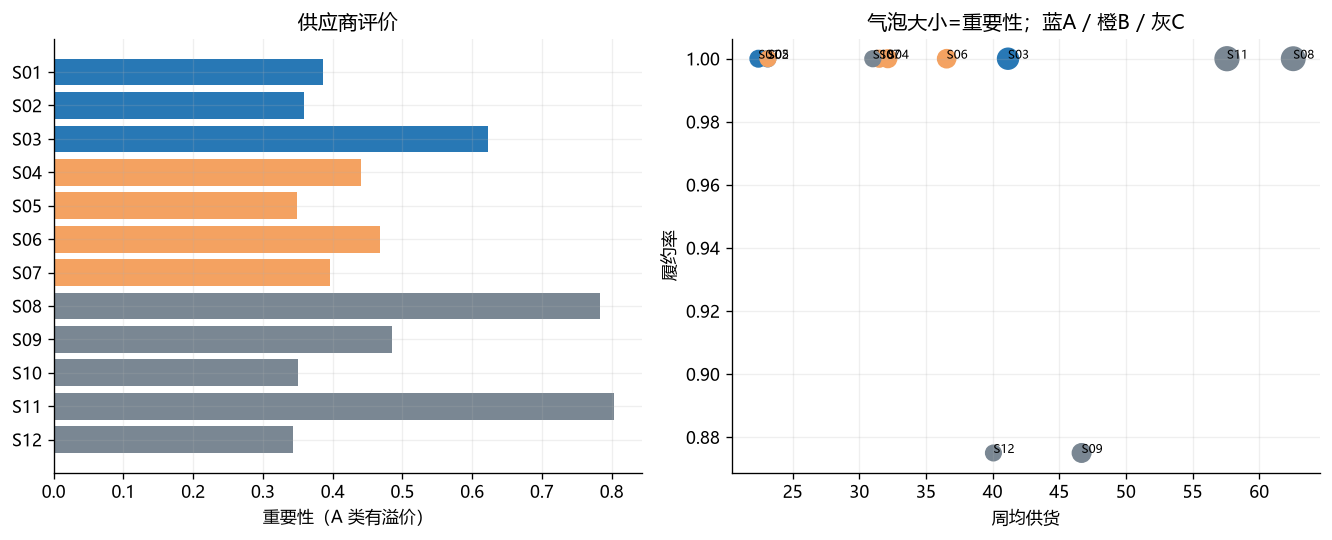

In [6]:
# 重要性评价：周均供货、履约率、历史最大 = 效益；变异系数 = 成本
# 并对稀缺的 A 类乘重要性溢价
Z2, w2 = entropy_weights(sup, {'周均供货': True, '履约率': True, '历史最大': True, '变异系数': False})
imp = topsis(Z2, w2)
atype = (sup['原料'] == 'A').astype(float)
sup['重要性'] = imp * (1 + 0.15 * atype)
sup['排名'] = sup['重要性'].rank(ascending=False).astype(int)

# 决策：选最少供应商，使每周期望供货之和 >= NEED
# 0-1 贪心：按 期望供货/已选惩罚，实际用枚举式动态规划因 n=12 可精确
expect = sup['周均供货'].to_numpy() * sup['履约率'].to_numpy()
n = len(sup)
best = (n + 1, None)
for mask in range(1, 1 << n):
    chosen = [i for i in range(n) if mask >> i & 1]
    if sum(expect[chosen]) >= NEED and len(chosen) < best[0]:
        best = (len(chosen), chosen)

chosen = best[1]
sup['入选最少集'] = 0
sup.loc[chosen, '入选最少集'] = 1

# 对照：只按重要性 Top-k 能否覆盖需求
order = np.argsort(-sup['重要性'].to_numpy())
k_need = next(k for k in range(1, n + 1) if expect[order[:k]].sum() >= NEED)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))
col = {'A': COLORS['blue'], 'B': COLORS['orange'], 'C': COLORS['gray']}
axes[0].barh(sup['供应商'][::-1], sup['重要性'][::-1],
             color=[col[t] for t in sup['原料'][::-1]])
axes[0].set_xlabel('重要性（A 类有溢价）'); axes[0].set_title('供应商评价')
axes[1].scatter(sup['周均供货'], sup['履约率'],
                s=200 * sup['重要性'] / sup['重要性'].max(),
                c=[col[t] for t in sup['原料']])
for _, r in sup.iterrows():
    axes[1].annotate(r['供应商'], (r['周均供货'], r['履约率']), fontsize=7)
axes[1].set_xlabel('周均供货'); axes[1].set_ylabel('履约率')
axes[1].set_title('气泡大小=重要性；蓝A / 橙B / 灰C')
fig.tight_layout()

dec = pd.DataFrame({
    '最少供应商数': [best[0]],
    '最少集': [','.join(sup.loc[chosen, '供应商'])],
    '若只按评价Top-k需': [k_need],
    '最少集周期望供货': [expect[chosen].sum()]
})
print('评价前 50 名 ≠ 维持生产的最小集合。第 2 问必须单独做覆盖优化。')
show_result(sup.sort_values('排名')[['供应商','原料','重要性','排名','入选最少集']].round(3))
show_result(dec.round(2), fig)

## 2.3 订购与转运怎样接到评价上？

选定供应商后：

1. 用历史周序列预测未来 24 周可供量（移动平均 / Holt / 分位数）；
2. 订购规划：$\min$ 成本，s.t. 到厂量满足产能、不超可供量；
3. 转运规划：把每周订单分配给 8 家转运商，运力 6000，目标是损耗最小；
4. 第 3 问把目标改成“成本 + 仓储体积”，并奖励 A、惩罚 C。

## 2.4 正式参赛还应补什么？

- 官方消耗：A/B/C 生产同一产能所需体积不同，必须按题面折算；
- 402 家无法枚举 $2^{402}$，要先用评价筛 80–100 家再做整数规划；
- 损耗率按转运商、按周预测，不要用一个全局平均数掩盖差异；
- 用历史“订购–供货”差验证履约率定义是否站得住。

# 案例三｜2024 国赛 C 题：农作物的种植策略

> 一个华北山村要决定未来几年每块地种什么。地有类型（平旱、水浇、大棚），作物有粮食、豆类、蔬菜、食用菌。还不能重茬、三年至少种一次豆，超产可能烂在地里或半价卖掉。小白第一反应“哪种利润高种哪种”一定会撞上约束。

## 3.1 专有名词

- **地块类型**：平旱地 / 梯田 / 山坡地通常一年一季、适合粮食；水浇地可种水稻或两季蔬菜；普通大棚蔬菜+食用菌；智慧大棚两季蔬菜。类型不对，再赚钱也不能种。
- **重茬**：同一块地连续两季（或跨年接下季）种同一种作物。题面说会减产，本课直接禁止。
- **豆类轮作**：豆类根上有根瘤菌，对土壤好。题面要求从 2023 年起，每个地块三年内至少种一次豆。**不能种豆的地块不要硬加这条约束**，否则模型会无解。
- **超产**：所有地块某种作物加起来的产量，超过该作物预期销量。超出部分：第 1 问(1) 当浪费，收入为 0；第 1 问(2) 按原价 50% 卖掉。
- **预期销量 $D_c$**：市场大概能按正常价格吃掉多少，单位吨。
- **亩产**：一亩地一季能收多少吨。
- **决策变量**：我们真正能决定的数，这里是“哪年、哪块地、哪一季、种哪一种、种多少亩”。

## 3.2 三问要交什么

**第 1 问：** 假设未来销量、成本、亩产、价格都和 2023 年一样。分别给出 2024–2030 年在“超产浪费”和“超产半价”下的种植表。

**第 2 问：** 销量、亩产、成本、价格都带题面给的不确定区间，给一个考虑风险的方案。

**第 3 问：** 再加作物之间的替代/互补、价格相关性。

官方是 34 块露天地 + 20 个大棚、几十种作物、7 年。本课用 4 块地 × 3 种作物 × 3 年把机制讲清楚。

## 3.3 第 1 问怎么写：先写变量、再写钱、再写约束

记 $a_{p,c,y,s}$ 为：地块 $p$、作物 $c$、年份 $y$、季节 $s$ 的种植亩数。

$$
Q_{c,y}=\sum_{p,s}a_{p,c,y,s}\cdot\mathrm{yield}_c.
$$

利润（核心，请慢看）：

$$
\pi=\sum_{c,y}\Big[p_c\min(Q_{c,y},D_{c,y})+\eta\,p_c\max(Q_{c,y}-D_{c,y},0)\Big]-\sum_{p,c,y,s}\mathrm{cost}_c\,a_{p,c,y,s}.
$$

|符号|人话|
|---|---|
|$a_{p,c,y,s}$|决策变量。这块地这季拿多少亩去种这种作物。休耕就是 0|
|$Q_{c,y}$|全村第 $y$ 年作物 $c$ 的总产量，吨|
|$\mathrm{yield}_c$|作物 $c$ 的亩产，吨/亩|
|$D_{c,y}$|该年该作物按正常价能卖掉的量|
|$p_c$|正常销售单价，元/吨（注意不是概率）|
|$\mathrm{cost}_c$|每亩种植成本，元/亩|
|$\min(Q,D)$|能按正常价卖掉的部分，取产量和需求的较小者|
|$\max(Q-D,0)$|多出来卖不掉的部分|
|$\eta$|超产部分的折价系数。浪费情景 $\eta=0$（多的全扔）；半价情景 $\eta=1/2$|
|$\pi$|总利润，元。第 1 问就是最大化它|

**为什么两张表会不一样：** $\eta$ 从 0 变成 1/2，多种蔬菜的边际收入从 0 变成半价，最优结构会从“克制、避免浪费”变成“多种一点也行”。

硬约束（写进论文时一条对应题面一句）：

$$
\begin{aligned}
&a_{p,c,y,s}=0 && \text{若地块类型不允许作物 }c\text{ 在第 }s\text{ 季种植},\\
&\sum_c a_{p,c,y,s}\le \mathrm{Area}_p && \text{一季种的亩数不能超过地块面积},\\
&a_{p,c,y,s}\cdot a_{p,c,\text{上一季}}=0 && \text{不能重茬},\\
&\sum_{y,s}a_{p,\text{豆},y,s}\ge \varepsilon_p && \text{仅对能种豆的地块：三年至少一次豆类}.
\end{aligned}
$$

|符号|人话|
|---|---|
|$\mathrm{Area}_p$|地块 $p$ 有多少亩|
|上一季|同一块地时间上紧挨着的上一季，跨年也算|
|$\varepsilon_p$|一个很小的正数或“至少种过一次”的 0-1 约束|

本课地块少，用“随机生成合法方案 + 局部改一季作物，谁利润高留谁”。正式 7 年全尺寸必须用混合整数规划（变量有整数亩数、0-1 选种）交给求解器。

## 3.4 第 2 问怎么写：不要只交一个点

题面说小麦玉米销量每年大约增 5%～10%，亩产 ±10%，成本每年大约 +5%，蔬菜价格大约 +5%，食用菌稳中有降。这些都是**区间**，不是一个数。

做法：按区间随机抽很多组参数（叫情景），每个方案会得到一串利润 $\pi^{(1)},\pi^{(2)},\ldots$。至少报告两个数：

$$
\mathbb{E}[\pi]\approx\frac{1}{M}\sum_{m=1}^{M}\pi^{(m)},\qquad
q_{0.10}(\pi)=\text{从低到高第 }10\%\text{ 那个利润}.
$$

|符号|人话|
|---|---|
|$M$|情景个数，本课 24 个，正式应更多|
|$\mathbb{E}[\pi]$|平均能赚多少|
|$q_{0.10}$|最倒霉的那一成情况里，你大概还能赚多少。越大越抗风险|

第 2 问可以最大化 $q_{0.10}$，而不是只最大化平均值。期望最高的方案，倒霉时可能摔得很惨。

## 3.5 第 3 问怎么写

替代：白菜贵了，萝卜需求上升。互补：饺子馅里白菜和肉一起动。不要对每种作物独立乱抖，而要用相关随机数（相关系数矩阵），再比较和第 2 问方案差在哪里。

In [7]:
plots = pd.DataFrame({
    '地块': ['平旱D1','水浇D2','普通棚G1','智慧棚G2'],
    '类型': ['平旱地','水浇地','普通大棚','智慧大棚'],
    '面积亩': [12.0, 8.0, 0.6, 0.6],
    '年季数': [1, 2, 2, 2]
})
crops = pd.DataFrame({
    '作物': ['小麦','黄豆','白菜'],
    '种类': ['粮食','豆类','蔬菜'],
    '亩产': [0.45, 0.22, 3.80],     # 吨/亩·季
    '成本': [420, 380, 1600],        # 元/亩
    '价格': [2600, 5400, 1800],      # 元/吨
    '预期销量': [6.0, 1.6, 5.5]      # 吨/年（全村教学口径）
})
# 合法性：平旱只能粮食/豆；水浇可粮/菜；棚可菜（普通棚第二季也可豆）
def allowed(plot_type, crop, season):
    if plot_type == '平旱地':
        return crop in ['小麦','黄豆'] and season == 1
    if plot_type == '水浇地':
        return (crop == '小麦' and season == 1) or (crop == '白菜')
    if plot_type == '普通大棚':
        return crop == '白菜' or (crop == '黄豆' and season == 2)
    if plot_type == '智慧大棚':
        return crop == '白菜'
    return False

print('地块与作物是压缩后的教学表。官方附件 1、2 要按地块编号和 2023 年种植初始化重茬。')
show_result(plots)
show_result(crops)

地块与作物是压缩后的教学表。官方附件 1、2 要按地块编号和 2023 年种植初始化重茬。


,地块,类型,面积亩,年季数
0,平旱D1,平旱地,12.0,1
1,水浇D2,水浇地,8.0,2
2,普通棚G1,普通大棚,0.6,2
3,智慧棚G2,智慧大棚,0.6,2


,作物,种类,亩产,成本,价格,预期销量
0,小麦,粮食,0.45,420,2600,6.0
1,黄豆,豆类,0.22,380,5400,1.6
2,白菜,蔬菜,3.80,1600,1800,5.5


In [8]:
# 穷举每年每块地每季的作物（含休耕），再检查重茬、豆类、面积
# 三年、4 地、最多 2 季，状态空间可接受
crop_ids = crops['作物'].tolist()
plot_rec = plots.to_dict('records')

def profit_of_plan(plan, surplus='waste', demand_scale=1.0, yield_scale=1.0, price_scale=None):
    """plan[year][plot][season] = crop or None"""
    if price_scale is None:
        price_scale = {c: 1.0 for c in crop_ids}
    prod = {c: 0.0 for c in crop_ids}
    cost = 0.0
    for y in range(3):
        for p, prow in enumerate(plot_rec):
            for s in range(prow['年季数']):
                c = plan[y][p][s]
                if c is None:
                    continue
                area = prow['面积亩']
                crow = crops.loc[crops['作物'] == c].iloc[0]
                prod[c] += area * crow['亩产'] * yield_scale
                cost += area * crow['成本']
    revenue = 0.0
    for c in crop_ids:
        q, dem = prod[c], crops.loc[crops['作物']==c, '预期销量'].iloc[0] * demand_scale
        price = crops.loc[crops['作物']==c, '价格'].iloc[0] * price_scale[c]
        sold = min(q, dem)
        extra = max(q - dem, 0)
        revenue += sold * price
        if surplus == 'half':
            revenue += extra * 0.5 * price
        # waste: extra contributes 0
    return revenue - cost, prod

def can_grow_bean(prow):
    return any(allowed(prow['类型'], '黄豆', s + 1) for s in range(prow['年季数']))


def feasible(plan):
    # 合法作物、重茬；仅对能种豆的地块要求三年至少一豆
    for p, prow in enumerate(plot_rec):
        last = None
        has_bean = False
        for y in range(3):
            for s in range(prow['年季数']):
                c = plan[y][p][s]
                if c is None:
                    last = None
                    continue
                if not allowed(prow['类型'], c, s + 1):
                    return False
                if last is not None and c == last:
                    return False
                if c == '黄豆':
                    has_bean = True
                last = c
        if can_grow_bean(prow) and not has_bean:
            return False
    return True

# 每块地每季的候选
cands = []
for p, prow in enumerate(plot_rec):
    pc = []
    for s in range(prow['年季数']):
        opts = [None] + [c for c in crop_ids if allowed(prow['类型'], c, s + 1)]
        pc.append(opts)
    cands.append(pc)

# 生成每块地自己的 3 年日程，再做笛卡尔（块数少）
from itertools import product

def plot_schedules(p):
    prow = plot_rec[p]
    seasons = prow['年季数']
    opts_by_season = cands[p]
    # 一年的选择
    year_choices = list(product(*opts_by_season))
    all_three = []
    for y123 in product(year_choices, repeat=3):
        plan_p = [list(y123[y]) for y in range(3)]
        all_three.append(plan_p)
    return all_three

# 先各自生成，再组合会很大；改为随机抽样 + 局部改进
r = np.random.default_rng(SEED)

def random_plan():
    plan = []
    for y in range(3):
        year = []
        for p, prow in enumerate(plot_rec):
            row = []
            for s in range(prow['年季数']):
                row.append(r.choice(cands[p][s]))
            year.append(row)
        plan.append(year)
    return plan

def copy_plan(plan):
    return [[row[:] for row in year] for year in plan]

def greedy_seed():
    """先满足豆类，再在合法且不重茬的前提下种毛利较高的作物。"""
    plan = [[[None] * plot_rec[p]['年季数'] for p in range(len(plot_rec))] for _ in range(3)]
    margin = {}
    for c in crop_ids:
        crow = crops.loc[crops['作物'] == c].iloc[0]
        margin[c] = crow['价格'] * crow['亩产'] - crow['成本']
    for p, prow in enumerate(plot_rec):
        last = None
        bean_done = not can_grow_bean(prow)
        for y in range(3):
            for s in range(prow['年季数']):
                opts = [c for c in cands[p][s] if c is not None and c != last]
                if not opts:
                    plan[y][p][s] = None
                    last = None
                    continue
                if (not bean_done) and ('黄豆' in opts) and y == 0:
                    pick = '黄豆'
                    bean_done = True
                else:
                    pick = max(opts, key=lambda c: margin[c])
                plan[y][p][s] = pick
                last = pick
    return plan

def search(surplus='waste', n_init=250, n_mut=180, **kw):
    best_val, best = -1e18, None
    seeds = [greedy_seed()] + [random_plan() for _ in range(n_init)]
    for plan in seeds:
        if not feasible(plan):
            continue
        val, _ = profit_of_plan(plan, surplus=surplus, **kw)
        if val > best_val:
            best_val, best = val, plan
    if best is None:
        return None, -1e18, {}
    for _ in range(n_mut):
        plan = copy_plan(best)
        p = int(r.integers(0, len(plot_rec)))
        y = int(r.integers(0, 3))
        s = int(r.integers(0, plot_rec[p]['年季数']))
        plan[y][p][s] = r.choice(cands[p][s])
        if feasible(plan):
            val, prod = profit_of_plan(plan, surplus=surplus, **kw)
            if val > best_val:
                best_val, best = val, plan
    _, prod = profit_of_plan(best, surplus=surplus, **kw)
    return best, best_val, prod

plan_w, val_w, prod_w = search('waste')
plan_h, val_h, prod_h = search('half')

def plan_to_table(plan):
    rows = []
    for y in range(3):
        for p, prow in enumerate(plot_rec):
            for s in range(prow['年季数']):
                rows.append({
                    '年': 2024 + y, '地块': prow['地块'], '季': s + 1,
                    '作物': plan[y][p][s] if plan[y][p][s] else '休耕'
                })
    return pd.DataFrame(rows)

cmp = pd.DataFrame({
    '情景': ['超产浪费', '超产半价'],
    '三年利润(元)': [val_w, val_h],
    **{f'{c}产量(吨)': [prod_w[c], prod_h[c]] for c in crop_ids}
})
print('半价出售会鼓励多产蔬菜；浪费情景则更克制，避免白菜烂在地里。')
show_result(cmp.round(2))
show_result(plan_to_table(plan_w))

半价出售会鼓励多产蔬菜；浪费情景则更克制，避免白菜烂在地里。


,情景,三年利润(元),小麦产量(吨),黄豆产量(吨),白菜产量(吨)
0,超产浪费,19872.0,5.4,2.77,6.84
1,超产半价,74023.2,5.4,5.68,104.88


,年,地块,季,作物
0,2024,平旱D1,1,小麦
1,2024,水浇D2,1,休耕
2,2024,水浇D2,2,休耕
3,2024,普通棚G1,1,休耕
4,2024,普通棚G1,2,白菜
5,2024,智慧棚G2,1,休耕
6,2024,智慧棚G2,2,白菜
7,2025,平旱D1,1,黄豆
8,2025,水浇D2,1,休耕
9,2025,水浇D2,2,休耕


,方案,期望利润,10%分位利润
0,超产半价点最优,79572.3,70275.4
1,最大化 10% 分位,80336.2,73719.1


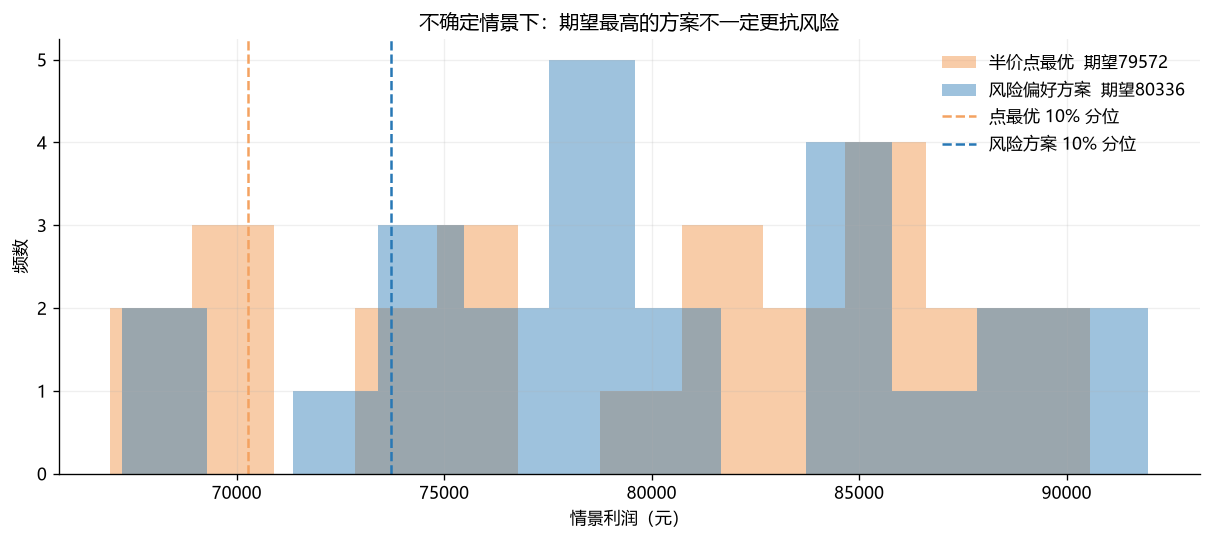

In [9]:
# 问题 2 教学版：亩产 ±10%、白菜价格 +5%/年、小麦销量 +7%/年，用 40 个情景看期望与 10% 分位
def scenario_eval(plan, n=24):
    vals = []
    for k in range(n):
        ys = rng.uniform(0.90, 1.10)
        ds = {'小麦': 1.07, '黄豆': rng.uniform(0.95, 1.05), '白菜': rng.uniform(0.95, 1.05)}
        # 销量按作物，这里用小麦放大、其他抖动的近似：对 demand 用加权
        demand_scale = 1.0
        price_scale = {'小麦': 1.0, '黄豆': 1.0, '白菜': 1.05}
        # 更细：按作物分别缩放销量——扩展 profit 函数的 demand 字典
        val, _ = profit_of_plan(plan, surplus='half', yield_scale=ys,
                                demand_scale=float(np.mean(list(ds.values()))),
                                price_scale=price_scale)
        vals.append(val)
    vals = np.array(vals)
    return vals.mean(), np.quantile(vals, 0.10), vals

# 在半价最优附近再搜一个“10% 分位”更好的方案
cands_plans = [plan_h]
for _ in range(36):
    p = copy_plan(plan_h)
    i = int(rng.integers(0, len(plot_rec)))
    y = int(rng.integers(0, 3))
    s = int(rng.integers(0, plot_rec[i]['年季数']))
    p[y][i][s] = rng.choice(cands[i][s])
    if feasible(p):
        cands_plans.append(p)

rows = []
best_q = (-1e18, None, None)
for i, p in enumerate(cands_plans):
    mu, q10, vs = scenario_eval(p)
    rows.append({'方案': i, '期望利润': mu, '10%分位': q10})
    if q10 > best_q[0]:
        best_q = (q10, p, vs)

risk_tbl = pd.DataFrame(rows).sort_values('10%分位', ascending=False).head(6)
mu_h, q_h, vs_h = scenario_eval(plan_h)
mu_r, q_r, vs_r = best_q[0], best_q[0], best_q[2]
# fix
mu_r = vs_r.mean(); q_r = np.quantile(vs_r, 0.10)

fig, ax = plt.subplots(figsize=(10.2, 4.6))
ax.hist(vs_h, bins=12, color=COLORS['orange'], alpha=0.55, label=f'半价点最优  期望{mu_h:.0f}')
ax.hist(vs_r, bins=12, color=COLORS['blue'], alpha=0.45, label=f'风险偏好方案  期望{mu_r:.0f}')
ax.axvline(q_h, color=COLORS['orange'], ls='--', label='点最优 10% 分位')
ax.axvline(q_r, color=COLORS['blue'], ls='--', label='风险方案 10% 分位')
ax.set_xlabel('情景利润（元）'); ax.set_ylabel('频数')
ax.set_title('不确定情景下：期望最高的方案不一定更抗风险')
ax.legend(frameon=False)
fig.tight_layout()
show_result(pd.DataFrame({
    '方案': ['超产半价点最优', '最大化 10% 分位'],
    '期望利润': [mu_h, mu_r],
    '10%分位利润': [q_h, q_r]
}).round(1), fig)

## 3.2 结果怎么读？

- “浪费”和“半价”改变的是超产的边际收益，因此最优种植结构会变。这正是第 1 问要两张表的原因。
- 第 2 问不要只交一个点估计方案。至少报告期望和低分位。银行信贷里的风险分，在这里变成了利润分布。
- 三年豆类约束会迫使部分高收益蔬菜让位。若模型从不种豆，一定是约束没写进去。

## 3.3 正式参赛还应补什么？

- 用地块编号、2023 年已种作物初始化重茬；
- 用整数规划 / 求解器处理 7 年全尺寸；
- 加入分散度、最小种植面积；
- 第 3 问用相关随机数生成替代/互补需求，而不是独立扰动。

# 案例四｜2023 美赛 D 题：Prioritizing the UN Sustainability Goals

> 联合国有 17 个可持续发展目标（SDG），例如无贫困、零饥饿、气候行动。它们互相扯着：发展工业可能有助于体面工作，却可能伤害气候。题目要你画关系网、排出优先级、证明这套优先级“有效”，并讨论某个目标已经达成或世界出事以后名单怎么变。

## 4.1 专有名词

- **SDG**：Sustainable Development Goals，可持续发展目标，一共 17 个，2015 年联合国通过。
- **网络 / 图**：点（17 个目标）+ 边（谁影响谁）。边可以带正负号：正 = 促进，负 = 制约。
- **缺口**：这个目标现在离“达成”还有多远。1 表示很远、很紧迫；0 表示基本达成。
- **枢纽 / 中心性**：有的目标连着很多别的目标，推它一下会带动一片，叫枢纽。
- **PageRank**：谷歌最初给网页排序的算法。谁被重要的节点指过来，谁就重要。这里用来给 SDG 打“网络地位”。
- **优先级**：不是分数好看就完了，而是“如果只能先推几个，先推谁”。
- **有效性**：题目点名要你评价 priority 好不好。必须给一个可计算的定义，例如“同样多的资源投进去，网络扩散后总进展多大”。
- **Leontief 扩散 / 投入产出**：经济学里“一部门增产会带动上下游”的矩阵算法。这里把资源向量“注入”网络，看最终每个目标动了多少。

## 4.2 题目每一问怎么写

**建网络。** 写一个 $17\times 17$ 矩阵 $A$。$A_{ji}$ 表示：目标 $i$ 前进一格，目标 $j$ 会被带着走多少。

|符号|人话|
|---|---|
|$A_{ji}>0$|$i$ 促进 $j$。例如教育（4）促进体面工作（8）|
|$A_{ji}<0$|$i$ 制约 $j$。例如工业（9）可能伤害水下生物（14）|
|$A_{ii}=0$|自己对自己的直接影响先不写，避免重复计算|

边从哪里来：文献、SDG 指标之间的相关、专家打分。本课用教学矩阵，**不是联合国官方矩阵**。论文必须声明来源。

**给每个目标打优先分。** 先算缺口 $g_i$（越大越紧迫），再算网络地位 $\pi_i$。PageRank：

把 $|A|$ 每列归一化得到转移矩阵 $P$（一列加起来为 1，表示“影响力往哪分配”），

$$
\pi=0.85\,P\pi+\frac{0.15}{17}\mathbf{1}.
$$

|符号|人话|
|---|---|
|$P$|忽略正负之后的“谁流向谁”的概率矩阵|
|$0.85$|按网络边走的比例（阻尼系数）。剩下 0.15 平均分给 17 个点，防止有的点谁也不连、算法卡死|
|$\mathbf{1}$|17 个 1 组成的向量|
|$\pi_i$|目标 $i$ 的枢纽分。大 = 在网里地位高|

极差标准化（把不同量纲拉到 0～1）后线性组合：

$$
S_i=0.55\,\widetilde g_i+0.45\,\widetilde\pi_i.
$$

|符号|人话|
|---|---|
|$\widetilde g_i$|缺口标准化后，1 = 本组最紧迫|
|$\widetilde\pi_i$|枢纽标准化后|
|$0.55,0.45$|更看重“现在缺得厉害”，还是“能带动别人”。必须做敏感性：改成 0.7/0.3 名单动不动|
|$S_i$|优先分，用来排序|

**评价优先级是否有效（题目原话 How did you evaluate）。** 把资源向量 $u$（17 个数，加起来为 1，表示资金/政治资本怎么分）注入网络：

$$
\Delta=(I-\alpha A)^{-1}u,\qquad \mathrm{Impact}(u)=\sum_{i=1}^{17}\Delta_i.
$$

|符号|人话|
|---|---|
|$u$|你的优先级变成的投资比例。只投 Top-5 就是那 5 个各 0.2，其余 0|
|$I$|$17\times 17$ 单位矩阵，对角为 1|
|$\alpha$|扩散强度，本课 0.45。太大可能让矩阵奇异（算不下去）|
|$(I-\alpha A)^{-1}$|把直接效应和一圈圈间接效应加总的数学工具|
|$\Delta_i$|目标 $i$ 最终获得的进展|
|$\mathrm{Impact}$|总进展。这就是本课对“有效”的定义|

对照三种 $u$：只投 Top-5、17 个平均分、只投缺口最大的几个。谁的 Impact 高，谁更有效。

**重要提醒：** 若你把“有效”定义成总进展，平均分散有时会赢，因为负向边会被摊薄。若定义成“最紧迫的 3 个目标进展了多少”，集中更好。论文必须写清你用哪一种，不能空说“我们的优先级科学合理”。

**某个 SDG 已达成。** 例如无贫困已达成：把 $A$ 里和第 1 个目标有关的行、列清零，把 $g_1$ 降到接近 0，重算 $S$。名单若几乎不动，说明你的边太弱，要重新标定。

**冲击（气候、疫情、战争）。** 例如气候压力：加大目标 13 对 14、15 的负向边，同时抬高 13 的缺口，看 $S$ 谁升谁降。变化最大的那些目标，才是网络方法比“静态打分表”多出来的洞见。

**10 年合理达成什么。** 不要宣布 17 个一起完成。写成：在资源约束下，哪些目标的缺口能降到某个阈值以下，哪些只能维持。

**给其他组织的迁移。** 同一套骨架：列出目标 → 画带符号的边 → 缺口 × 枢纽 → 用扩散检验优先级。公司把 SDG 换成“部门 KPI”即可。

Top-5 集中投入的网络总进展 1.237，17 个目标平均投入 1.275。
若平均投入更高，说明“有效性”若定义为总进展，集中并不自动更优；论文里要写清有效性指标。


,SDG,缺口,网络枢纽,优先分
7,8 体面工作,0.791,1.000,0.969
12,13 气候行动,0.780,0.842,0.876
0,1 无贫困,0.820,0.431,0.709
14,15 陆地生物,0.545,0.978,0.693
9,10 减少不平等,0.700,0.468,0.599
2,3 健康,0.501,0.779,0.544
5,6 清洁饮水,0.372,0.951,0.493
11,12 负责任消费,0.614,0.398,0.471


,SDG,优先分_达成贫困后
7,8 体面工作,0.963
12,13 气候行动,0.947
14,15 陆地生物,0.817
9,10 减少不平等,0.704
5,6 清洁饮水,0.677
2,3 健康,0.605


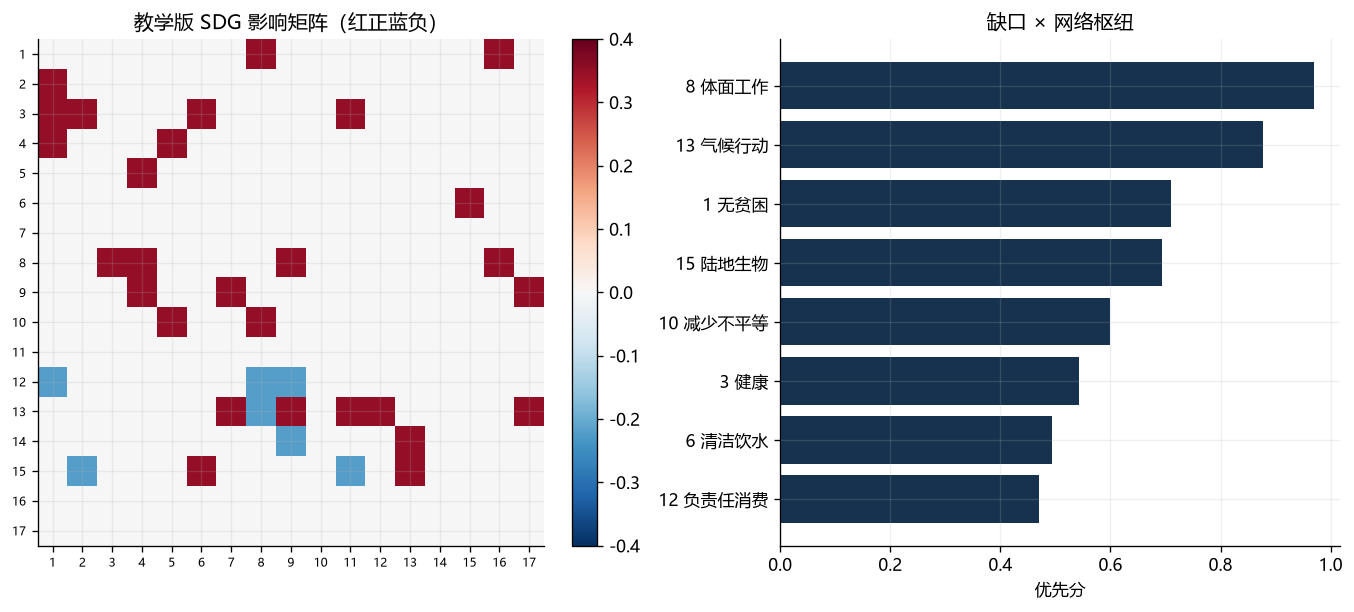

In [10]:
sdg_name = {
    1:'无贫困',2:'零饥饿',3:'健康',4:'教育',5:'性别平等',6:'清洁饮水',
    7:'清洁能源',8:'体面工作',9:'产业创新',10:'减少不平等',11:'可持续城市',
    12:'负责任消费',13:'气候行动',14:'水下生物',15:'陆地生物',16:'和平正义',17:'伙伴关系'
}
# 教学影响矩阵：+ 促进，- 制约。不是联合国官方矩阵。
A = np.zeros((17, 17))
pos = [(1,2),(1,3),(1,4),(2,3),(3,8),(4,5),(4,8),(4,9),(6,3),(6,15),
       (7,9),(7,13),(8,1),(8,10),(9,8),(9,13),(13,15),(13,14),(15,6),
       (16,1),(16,8),(17,9),(17,13),(5,4),(5,10),(11,3),(11,13),(12,13)]
neg = [(8,13),(9,12),(9,14),(2,15),(11,15),(8,12),(1,12)]
for i, j in pos:
    A[j-1, i-1] += 0.35   # 列影响行：i 进展 → j
for i, j in neg:
    A[j-1, i-1] -= 0.22

# 自身缺口：1=缺口大（更紧迫）
r = np.random.default_rng(7)
gap = np.clip(r.normal(0.55, 0.18, 17), 0.15, 0.95)
gap[0], gap[12], gap[9] = 0.82, 0.78, 0.70   # 贫困、气候、不平等缺口大

# 网络地位：加权 PageRank 风格，用 |A| 的权威分
W = np.abs(A)
out = W.sum(axis=0, keepdims=True) + 1e-9
P = W / out
pr = np.ones(17) / 17
for _ in range(40):
    pr = 0.85 * P @ pr + 0.15 / 17
pr = pr / pr.max()

# 组合评价：缺口 0.55 + 枢纽 0.45
score = 0.55 * minmax_norm(gap) + 0.45 * minmax_norm(pr)
priority = pd.DataFrame({
    'SDG': [f'{i+1} {sdg_name[i+1]}' for i in range(17)],
    '缺口': gap, '网络枢纽': pr, '优先分': score
}).sort_values('优先分', ascending=False)

# 有效性：投入向量 u（只投 Top-5）经过 (I-αA)^{-1} 扩散后的总进展
I = np.eye(17)
alpha = 0.45
try:
    spread = np.linalg.inv(I - alpha * A)
except np.linalg.LinAlgError:
    spread = np.linalg.pinv(I - alpha * A)

def impact(top_k):
    u = np.zeros(17)
    idx = priority.index[:top_k]  # original sdg index after sort? wait index is original labels
    # priority index 仍是 0-16
    u[priority.index[:top_k].to_numpy()] = 1.0 / top_k
    g = spread @ u
    return float(g.sum()), g

imp5, g5 = impact(5)
imp_eq, _ = impact(17)

# 若 SDG1 已达成：去掉第 0 行/列的影响，重算
A2 = A.copy(); A2[0, :] = 0; A2[:, 0] = 0
gap2 = gap.copy(); gap2[0] = 0.05
W2 = np.abs(A2); P2 = W2 / (W2.sum(axis=0, keepdims=True) + 1e-9)
pr2 = np.ones(17) / 17
for _ in range(40):
    pr2 = 0.85 * P2 @ pr2 + 0.15 / 17
score2 = 0.55 * minmax_norm(gap2) + 0.45 * minmax_norm(pr2 / pr2.max())
priority2 = pd.DataFrame({
    'SDG': [f'{i+1} {sdg_name[i+1]}' for i in range(17)],
    '优先分_达成贫困后': score2
}).sort_values('优先分_达成贫困后', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11.4, 5.2))
im = axes[0].imshow(A, cmap='RdBu_r', vmin=-0.4, vmax=0.4)
axes[0].set_title('教学版 SDG 影响矩阵（红正蓝负）')
axes[0].set_xticks(range(17)); axes[0].set_yticks(range(17))
axes[0].set_xticklabels(range(1, 18), fontsize=7)
axes[0].set_yticklabels(range(1, 18), fontsize=7)
plt.colorbar(im, ax=axes[0], fraction=0.046)
top = priority.head(8)
axes[1].barh(top['SDG'][::-1], top['优先分'][::-1], color=COLORS['navy'])
axes[1].set_xlabel('优先分'); axes[1].set_title('缺口 × 网络枢纽')
fig.tight_layout()
print(f'Top-5 集中投入的网络总进展 {imp5:.3f}，17 个目标平均投入 {imp_eq:.3f}。')
print('若平均投入更高，说明“有效性”若定义为总进展，集中并不自动更优；论文里要写清有效性指标。')
show_result(priority.head(8).round(3))
show_result(priority2.head(6).round(3), fig)

In [11]:
# 冲击：气候压力加强 13 列对 14/15 的负向，同时抬高 13 的缺口
A_shock = A.copy()
A_shock[13, 12] -= 0.15
A_shock[14, 12] -= 0.15
gap_s = gap.copy(); gap_s[12] = min(0.98, gap_s[12] + 0.12)
W_s = np.abs(A_shock)
P_s = W_s / (W_s.sum(axis=0, keepdims=True) + 1e-9)
pr_s = np.ones(17) / 17
for _ in range(40):
    pr_s = 0.85 * P_s @ pr_s + 0.15 / 17
score_s = 0.55 * minmax_norm(gap_s) + 0.45 * minmax_norm(pr_s / pr_s.max())
shock_tbl = pd.DataFrame({
    'SDG': [f'{i+1} {sdg_name[i+1]}' for i in range(17)],
    '基准优先分': score,
    '气候冲击后': score_s,
    '变化': score_s - score
}).sort_values('变化', ascending=False)

print('冲击之后，优先分变化最大的目标，才是网络方法比“静态打分表”多出来的洞见。')
show_result(shock_tbl.head(6).round(3))

冲击之后，优先分变化最大的目标，才是网络方法比“静态打分表”多出来的洞见。


,SDG,基准优先分,气候冲击后,变化
12,13 气候行动,0.876,0.919,0.043
16,17 伙伴关系,0.000,0.000,0.000
5,6 清洁饮水,0.493,0.484,-0.009
13,14 水下生物,0.289,0.278,-0.011
3,4 教育,0.184,0.172,-0.012
8,9 产业创新,0.261,0.239,-0.022


## 4.3 怎样评价“优先级是否有效”？

题目明确问 How did you evaluate the effectiveness。不要只说“我们觉得合理”。本课用的可计算定义是：

> 把资源向量 $u$ 注入网络，经过 $(I-\alpha A)^{-1}$ 扩散后的总进展。

对照策略：平均分配、只投缺口最大、只投枢纽。若你的优先级在对照之上，才算有效。

“10 年合理达成”应写成：在预算约束下，哪些目标的缺口能降到阈值以下，而不是宣布 17 个一起完成。

## 4.4 正式参赛还应补什么？

- 边的权重用文献、SDG 指标相关、专家调查标定；
- 区分相关与因果；
- 国家尺度案例（一个中等收入国家 vs 一个小岛国）说明优先级会换；
- 备忘录面向联合国官员，不要只堆中心性公式。

# 5. 四道赛题放在一起：评价什么，决策什么？

|案例|评价对象|权重/集结|决策变量|硬约束|对照策略|
|---|---|---|---|---|---|
|信贷|企业风险/信誉|熵权-TOPSIS|放贷 0-1、额度、利率|总额、10–100 万、4%–15%|只贷 A 级 / 平均分配|
|供应商|供货重要性|熵权-TOPSIS + A 溢价|入选集合、周订购|需求覆盖、运力|评价 Top-k|
|种植|（约束为主）|情景利润分布|地块-作物-年-季|重茬、豆类、类型匹配|去年种什么今年还种|
|SDG|目标缺口×枢纽|组合赋权 + 网络扩散|优先级 / 资源份额|政治资本有限|平均投资|

## 一句话选择法

- 题目先问“谁更重要 / 谁风险更大” → 先评价；
- 题目接着问“总额固定怎么分 / 24 周怎么订 / 七年怎么种” → 必须规划；
- 对象之间有促进或制约 → 上网络，不要当独立打分；
- 未来数字带 ±5%、±10% → 至少做情景和低分位，不要只交一张表。

## 真正通用的能力

$$
\boxed{准则可计算 \rightarrow 方向正确 \rightarrow 主客观权重对照 \rightarrow 排序稳定 \rightarrow 写成规划 \rightarrow 和朴素策略比 \rightarrow 扰动后还成立}
$$

# 6. 从 Notebook 到一篇竞赛论文：建议目录

1. **摘要**：对象、准则数、主方法、关键名单/方案、相对对照策略改进多少。
2. **问题重述**：评价问什么、决策问什么，分问对应。
3. **指标体系**：每个指标的公式、方向、数据列。
4. **赋权与一致性**：AHP 的 $CR$、熵权、组合 $\lambda$、Spearman。
5. **评价结果**：得分表、分级、贡献分解。
6. **决策模型**：变量、目标、约束，逐条对应题面。
7. **求解与对照**。
8. **敏感性 / 情景 / 突发冲击**。
9. **优点、局限、改进**。
10. **参考文献与可复现代码**。

## 评委讨厌的两句话

- “本文采用 AHP-熵权-TOPSIS-灰色-模糊，结果科学合理。”——方法多不等于对。
- “由模型得最优方案如下。”——不和任何基线比，不知道优在哪里。

# 7. 练习：把课件变成你自己的能力

## 练习 1：信贷权重扰动

把熵权每个分量 ±20% 后重新归一，重算 TOPSIS。报告放贷名单 Top-8 的平均重合率。重合率低于 60% 就要回头检查准则是不是共线。

## 练习 2：供应商最小集

禁止使用 A 类后，最少供应商数增加几家？这能帮助写“A 类为什么重要”。

## 练习 3：种植豆类约束

去掉“三年至少一次豆类”，利润会上升多少？上升的部分就是该约束的影子价格，论文里很好用。

## 练习 4：SDG 达成实验

分别令 SDG 1、SDG 13 已达成，比较新优先级。若两次名单几乎一样，说明网络边太弱，需要重新标定。

## 练习 5：独立选题

从奖学金评定、医院选址、公交线路、供应商招标、校园食堂评价里选一题。必须提交：准则表（含方向和公式）、两套权重、一张得分表、一个带约束的决策、一次敏感性、三条局限。

# 8. 最后总结

评价与决策类赛题的核心突破，不是会背 AHP 和 TOPSIS 的步骤，而是：

1. 先分清：这一问是在打分，还是在选行动；
2. 准则必须可计算、方向必须正确、量纲必须一致；
3. 权重至少两套，并用排序相关证明结论不脆弱；
4. 评价分数要写成筛选、目标或风险预算，否则决策仍是拍脑袋；
5. 约束比目标更容易决定方案像不像现实；
6. 任何“最优”都要和朴素策略、扰动情景比较。

四个最短记忆：

$$
\boxed{信贷：评价风险 \rightarrow 违约与流失 \rightarrow 额度利率规划}
$$

$$
\boxed{供应商：重要性排序 \neq 最小覆盖集合}
$$

$$
\boxed{种植：合法约束先于利润，超产规则会改变结构}
$$

$$
\boxed{SDG：缺口\times枢纽，再用网络扩散检验优先级}
$$

最重要的不是指标体系有多长，而是：**每一个分数都能指出数据，每一个决策都能指出约束，换一组合理权重后结论还在。**